## Halloween Candy Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
halloween=pd.read_csv("candy-data.csv")
halloween.head(10)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
5,Almond Joy,1,0,0,1,0,0,0,1,0,0.465,0.767,50.347546
6,Baby Ruth,1,0,1,1,1,0,0,1,0,0.604,0.767,56.914547
7,Boston Baked Beans,0,0,0,1,0,0,0,0,1,0.313,0.511,23.417824
8,Candy Corn,0,0,0,0,0,0,0,0,1,0.906,0.325,38.010963
9,Caramel Apple Pops,0,1,1,0,0,0,0,0,0,0.604,0.325,34.517681


In [3]:
subset=halloween.iloc[:,1:-3]
subset.head()

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus
0,1,0,1,0,0,1,0,1,0
1,1,0,0,0,1,0,0,1,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0


## Principal Component Analysis

In [4]:
pca =PCA(n_components=2)

In [5]:
pca.fit(subset)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
pca.explained_variance_ratio_

array([0.45736631, 0.15454393])

In [7]:
candy_2d=pd.DataFrame(pca.transform(subset))
candy_2d

,0,1
0,1.305021,-0.335978
1,1.123628,-0.294698
2,0.034733,-0.204088
3,0.034733,-0.204088
4,-0.469043,-0.565369
...,...,...
80,-0.469043,-0.565369
81,-0.661159,-0.936544
82,-0.844989,0.166781
83,0.041691,-0.700752


<Axes: xlabel='0', ylabel='1'>

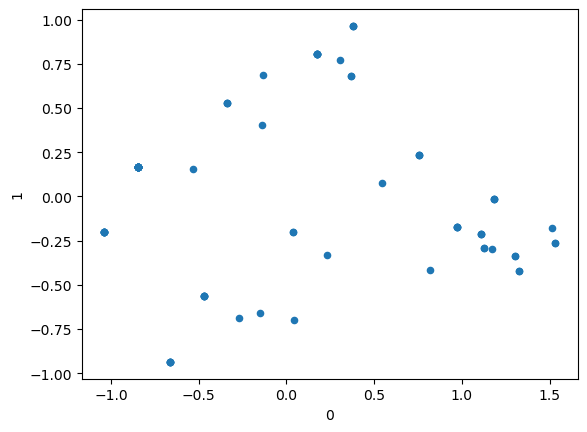

In [8]:
candy_2d.plot(kind='scatter',x=0,y=1)

In [9]:
halloween

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282
81,Warheads,0,1,0,0,0,0,1,0,0,0.093,0.116,39.011898
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,0.186,0.267,41.904308


<Axes: xlabel='x_jitter', ylabel='y_jitter'>

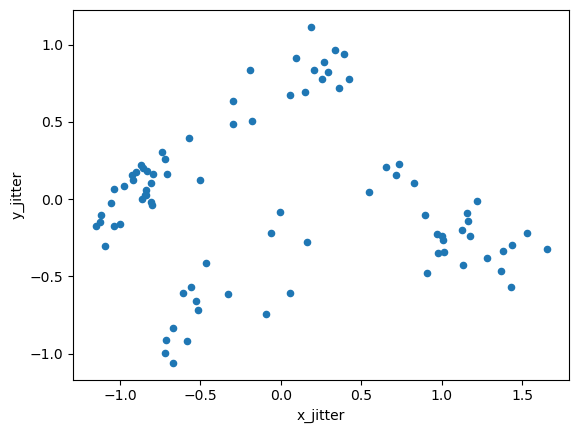

In [10]:
halloween['x_jitter']=candy_2d[0]+np.random.randn(85)*0.1
halloween['y_jitter']=candy_2d[1]+np.random.randn(85)*0.1
halloween.plot(kind='scatter',x='x_jitter',y='y_jitter')

In [11]:
halloween

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,x_jitter,y_jitter
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725,1.436110,-0.297138
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936,1.367386,-0.462861
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086,-0.006902,-0.084390
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505,-0.062023,-0.216563
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465,-0.558149,-0.569698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282,-0.610549,-0.606631
81,Warheads,0,1,0,0,0,0,1,0,0,0.093,0.116,39.011898,-0.583172,-0.920786
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519,-0.867160,0.222895
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,0.186,0.267,41.904308,0.055352,-0.609175


In [12]:
halloween.to_csv('halloween_pca.csv')